In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import geopandas as gpd
from shapely import wkt

In [26]:
# with open('..\\..\\data\\ecm1\\ecm1_fullmodel_novel.csv') as f:
#     for _ in range(2):
#         print(f.readline())

In [27]:
calgary = pd.read_csv('..\\..\\data\\ecm1\\City_Boundary_20261005.csv')

print(calgary.columns.tolist())   # find the column holding the geometry text

calgary['geometry'] = calgary['MULTIPOLYGON'].apply(wkt.loads)

gdf = gpd.GeoDataFrame(calgary, geometry='geometry', crs='EPSG:4326')

['CITY', 'MULTIPOLYGON', 'CREATED_DT']


In [28]:
# pb = gpd.read_file('..\\..\\data\\Plate_Boundaries.shp')

# print(pb.columns.tolist())   # find the column holding the geometry text

In [29]:
d_E = pd.read_csv('..\\..\\data\\ecm1\\ecm1_fullmodel_novel.csv', header=None, skiprows=1,
                names=['num', 'long', 'lat', 'hcc','sed','hc','type','z1','z2', 'z3','th1', 'th2', 'th3','rho1', 'rho2', 'rho3', 'rho_man'])
print(d_E)

         num   long   lat      hcc     sed       hc  type       z1       z2  \
0          1 -179.5  89.5   6.4459  2.3303   8.7762  SOCE   4.4574   6.5846   
1          2 -178.5  89.5   6.3511  2.3344   8.6854  SOCE   4.4302   6.5261   
2          3 -177.5  89.5   6.2512  2.3398   8.5910  SOCE   4.4027   6.4656   
3          4 -176.5  89.5   6.1516  2.3463   8.4980  SOCE   4.3764   6.4064   
4          5 -175.5  89.5   6.0578  2.3520   8.4098  SOCE   4.3510   6.3501   
...      ...    ...   ...      ...     ...      ...   ...      ...      ...   
64795  64796  175.5 -89.5  39.0010  0.0000  39.0010  PLAT  12.8703  25.7406   
64796  64797  176.5 -89.5  39.0014  0.0000  39.0014  PLAT  12.8705  25.7409   
64797  64798  177.5 -89.5  39.0018  0.0000  39.0018  PLAT  12.8706  25.7412   
64798  64799  178.5 -89.5  39.0023  0.0000  39.0023  PLAT  12.8708  25.7415   
64799  64800  179.5 -89.5  39.0029  0.0000  39.0029  PLAT  12.8709  25.7419   

            z3      th1      th2      th3      rho1

## making a global grid with ecm1

In [30]:
d_E_grid_hcc = d_E.pivot(index='lat', columns='long', values='hcc')

lat = d_E_grid_hcc.index.values; long = d_E_grid_hcc.columns.values; hcc_d_E = d_E_grid_hcc.values

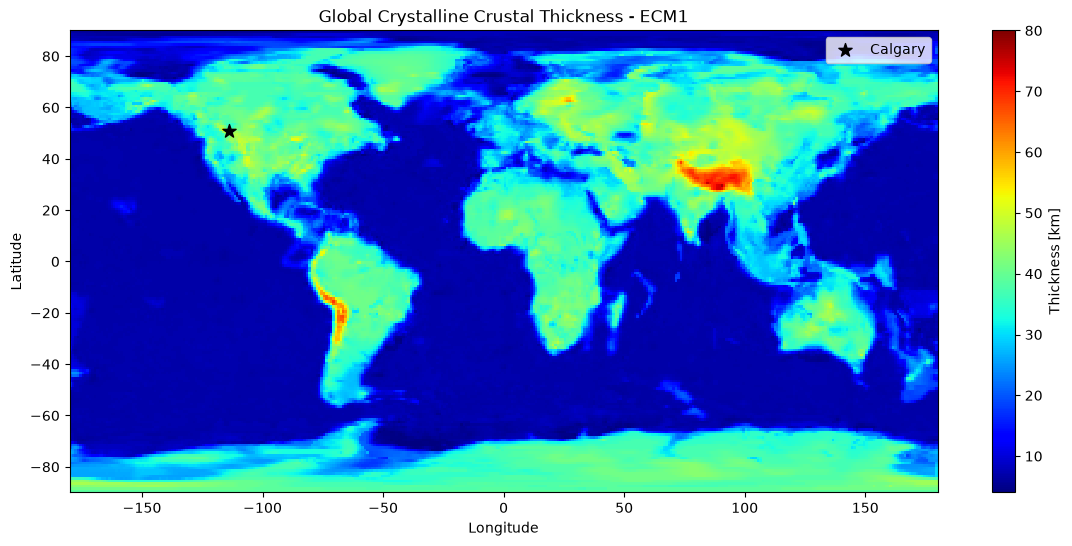

In [31]:
fig, ax0 = plt.subplots(figsize=(14, 6))

pcm_hcc_d_E = ax0.pcolormesh(long, lat, hcc_d_E, cmap='jet', vmax=80)
fig.colorbar(pcm_hcc_d_E, label='Thickness [km]')
ax0.scatter(-114.03, 51.02, marker='*', color='black', s=100, label='Calgary')


ax0.set_title('Global Crystalline Crustal Thickness - ECM1')
ax0.set_xlabel('Longitude')
ax0.set_ylabel('Latitude')

plt.legend()

plt.savefig('..\\..\\figures\\ecm1\\hcc_global_grid.png', dpi=400, bbox_inches='tight')
plt.show()


### now making AB!

In [32]:
long_min, long_max = -131, -112
lat_min, lat_max = 38, 54

In [33]:
d_E_na = d_E[(d_E['long'].between(long_min, long_max)) & (d_E['lat'].between(lat_min, lat_max))]

d_E_na_grid_hcc = d_E_na.pivot(index='lat', columns='long', values='hcc')

lat_na_hcc = d_E_na_grid_hcc.index.values; long_na_hcc = d_E_na_grid_hcc.columns.values; hcc_na = d_E_na_grid_hcc.values

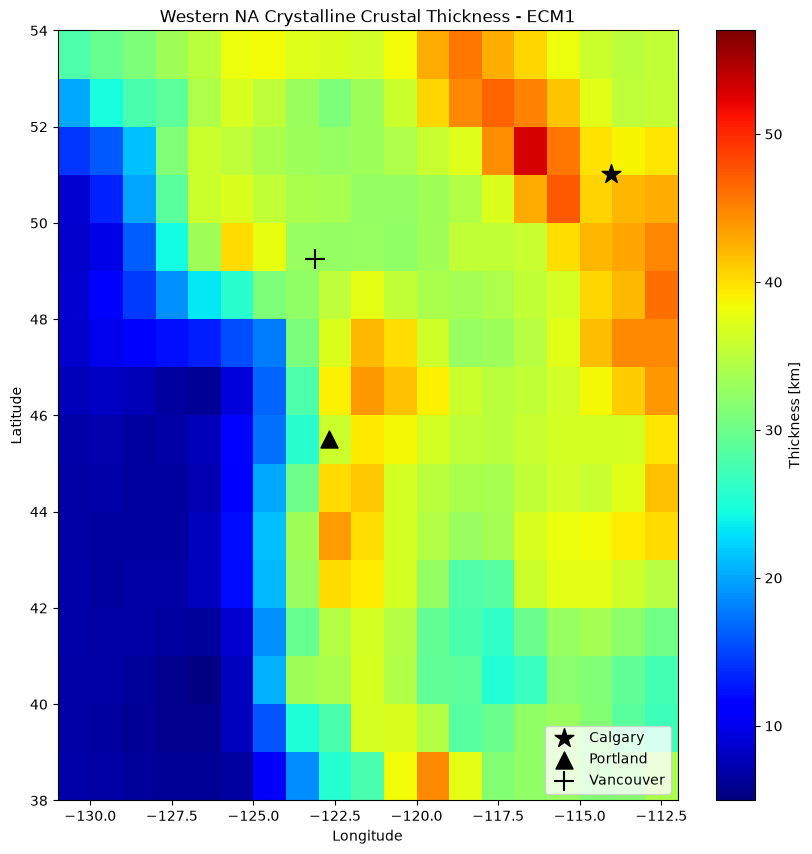

In [34]:
fig, ax00 = plt.subplots(figsize=(10, 10))

pcm_hcc_na = ax00.pcolormesh(long_na_hcc, lat_na_hcc, hcc_na, cmap='jet', vmax=57)
fig.colorbar(pcm_hcc_na, ax=ax00, label='Thickness [km]')
ax00.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax00.scatter(-122.68, 45.52, marker='^', color='black', s=150, label='Portland')
ax00.scatter(-123.12, 49.26, marker='+', color='black', s=200, label='Vancouver')

# ax00.set_aspect(1 / np.cos(np.deg2rad((lat_min + lat_max) / 2)))

ax00.set_title('Western NA Crystalline Crustal Thickness - ECM1')
ax00.set_xlabel('Longitude')
ax00.set_ylabel('Latitude')

plt.legend(loc='lower right')

plt.savefig('..\\..\\figures\\ecm1\\hcc_cad_grid.png', dpi=400, bbox_inches='tight')
plt.show()

## now crust 1.0 to compare...

In [35]:
d_cru = pd.read_csv('..\\..\\data\\crust1.0\\total_crust_thick.csv', header=None, skiprows=0,
                names=['long', 'lat', 't'])
print(d_cru)

d_sed = pd.read_csv('..\\..\\data\\crust1.0\\sed_thick.csv', header=None, skiprows=0,
                names=['long', 'lat', 's'])
print(d_sed)

        long   lat      t
0     -179.5  89.5   8.06
1     -178.5  89.5   8.08
2     -177.5  89.5   8.08
3     -176.5  89.5   8.09
4     -175.5  89.5   8.09
...      ...   ...    ...
64795  175.5 -89.5  39.00
64796  176.5 -89.5  39.00
64797  177.5 -89.5  39.00
64798  178.5 -89.5  39.00
64799  179.5 -89.5  39.00

[64800 rows x 3 columns]
        long   lat    s
0     -179.5  89.5  1.3
1     -178.5  89.5  1.3
2     -177.5  89.5  1.3
3     -176.5  89.5  1.3
4     -175.5  89.5  1.3
...      ...   ...  ...
64795  175.5 -89.5  1.5
64796  176.5 -89.5  1.5
64797  177.5 -89.5  1.5
64798  178.5 -89.5  1.5
64799  179.5 -89.5  1.5

[64800 rows x 3 columns]


In [36]:
d_cru_grid = d_cru.pivot(index='lat', columns='long', values='t')

lat = d_cru_grid.index.values; long = d_cru_grid.columns.values; t = d_cru_grid.values


d_sed_grid = d_sed.pivot(index='lat', columns='long', values='s')

lat = d_sed_grid.index.values; long = d_sed_grid.columns.values; s = d_sed_grid.values

In [37]:
crust1_res = t - s
print(crust1_res)

[[37.51 37.51 37.5  ... 37.5  37.5  37.5 ]
 [40.58 40.58 40.58 ... 40.7  40.7  40.7 ]
 [42.67 42.66 42.66 ... 42.6  42.6  42.7 ]
 ...
 [ 7.06  7.05  7.04 ...  7.13  7.1  11.41]
 [ 7.29  7.33  7.32 ...  7.29  7.3  11.86]
 [ 6.76  6.78  6.78 ...  7.5   7.5  11.01]]


> total crust 1.0

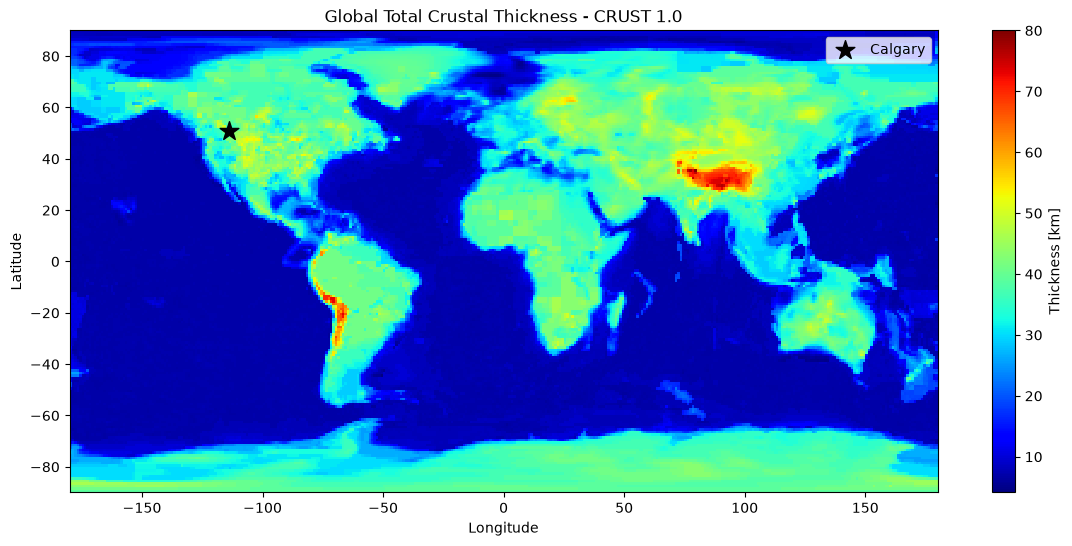

In [38]:
fig, ax1 = plt.subplots(figsize=(14, 6))

pcm_cru = ax1.pcolormesh(long, lat, t, cmap='jet', vmax=80)
fig.colorbar(pcm_cru, label='Thickness [km]')
ax1.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')


ax1.set_title('Global Total Crustal Thickness - CRUST 1.0')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

plt.legend()

plt.savefig('..\\..\\figures\\ecm1\\crust1.0_global_grid.png', dpi=400, bbox_inches='tight')
plt.show()

> crystalline crust 1.0

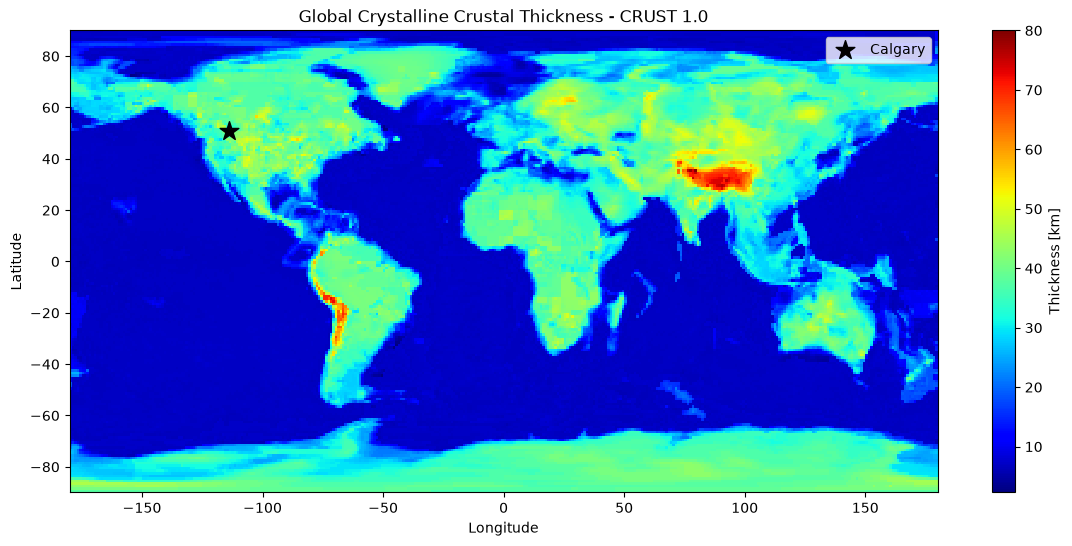

In [39]:
fig, ax10 = plt.subplots(figsize=(14, 6))

pcm_cru_res = ax10.pcolormesh(long, lat, crust1_res, cmap='jet', vmax=80)
fig.colorbar(pcm_cru_res, label='Thickness [km]')
ax10.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')

ax10.set_title('Global Crystalline Crustal Thickness - CRUST 1.0')
ax10.set_xlabel('Longitude')
ax10.set_ylabel('Latitude')

plt.legend()

plt.savefig('..\\..\\figures\\ecm1\\res_crust1.0_global_grid.png', dpi=400, bbox_inches='tight')
plt.show()

### and AB with CRUST 1.0...

In [40]:
d_cru_na = d_cru[(d_cru['long'].between(long_min, long_max)) & (d_cru['lat'].between(lat_min, lat_max))]

d_cru_na_grid = d_cru_na.pivot(index='lat', columns='long', values='t')

lat = d_cru_na_grid.index.values; long = d_cru_na_grid.columns.values; t_na = d_cru_na_grid.values

In [41]:
d_sed_na = d_sed[(d_sed['long'].between(long_min, long_max)) & (d_sed['lat'].between(lat_min, lat_max))]

d_sed_na_grid = d_sed_na.pivot(index='lat', columns='long', values='s')

lat = d_sed_na_grid.index.values; long = d_sed_na_grid.columns.values; s_na = d_sed_na_grid.values

In [42]:
crust1_res_na = t_na - s_na

In [43]:
print(crust1_res_na)

[[ 6.81  6.75  6.41  6.14  5.84  6.89  9.4  19.99 20.46 26.88 38.73 39.5
  35.36 33.01 33.57 33.86 31.2  30.8  36.26]
 [ 6.82  6.74  6.5   5.18  5.27  6.96 12.51 27.22 23.9  37.02 37.55 33.87
  31.05 32.   32.77 33.08 30.42 29.34 28.56]
 [ 6.8   6.79  6.16  6.02  5.62  6.43 24.13 30.05 32.61 36.89 36.9  29.72
  30.74 27.38 27.38 31.5  30.44 28.39 29.36]
 [ 6.83  6.8   6.76  6.61  6.36  6.   19.52 26.8  35.45 37.27 36.31 28.2
  29.18 29.5  32.49 33.61 33.89 33.61 35.73]
 [ 6.82  6.63  6.7   6.76  7.3  11.63 20.36 34.36 39.88 38.37 37.84 32.82
  27.86 29.39 41.15 39.5  39.9  37.56 35.54]
 [ 6.73  6.66  6.55  6.61  6.96 10.74 21.36 36.47 43.63 39.84 35.08 33.12
  32.77 33.09 38.38 40.94 38.5  40.06 41.35]
 [ 6.88  6.87  6.73  6.31  5.99  9.83 21.07 29.28 35.95 41.   34.63 34.4
  34.56 32.13 34.14 37.45 35.21 35.25 42.51]
 [ 6.85  6.82  6.32  7.29  6.76 10.76 20.12 22.36 38.11 38.28 38.67 36.68
  35.01 34.84 36.   37.45 37.76 36.77 40.11]
 [ 7.99  9.2   5.99  5.67  6.14 10.77 21.26 28.13 4

> total crust 1.0

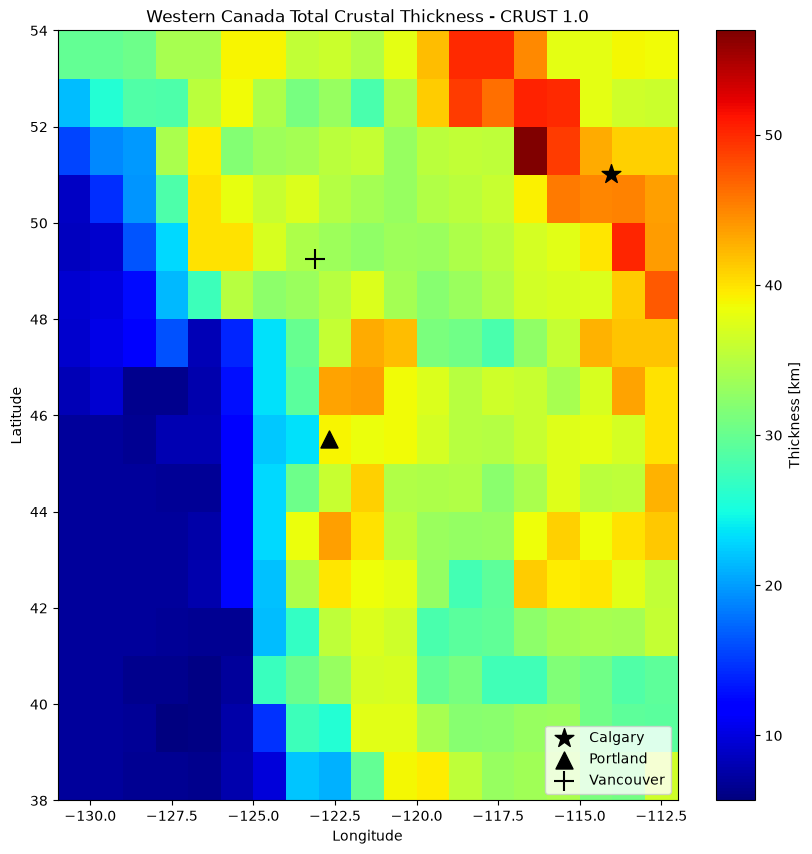

In [44]:
fig, ax11 = plt.subplots(figsize=(10, 10))

pcm_cru_na = ax11.pcolormesh(long, lat, t_na, cmap='jet')
fig.colorbar(pcm_cru_na, ax=ax11, label='Thickness [km]')
ax11.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax11.scatter(-122.68, 45.52, marker='^', color='black', s=150, label='Portland')
ax11.scatter(-123.12, 49.26, marker='+', color='black', s=200, label='Vancouver')

ax11.set_title('Western Canada Total Crustal Thickness - CRUST 1.0')
ax11.set_xlabel('Longitude')
ax11.set_ylabel('Latitude')

plt.legend(loc='lower right')

plt.savefig('..\\..\\figures\\ecm1\\crust1.0_cad_grid.png', dpi=400, bbox_inches='tight')
plt.show()

> crystalline crust 1.0

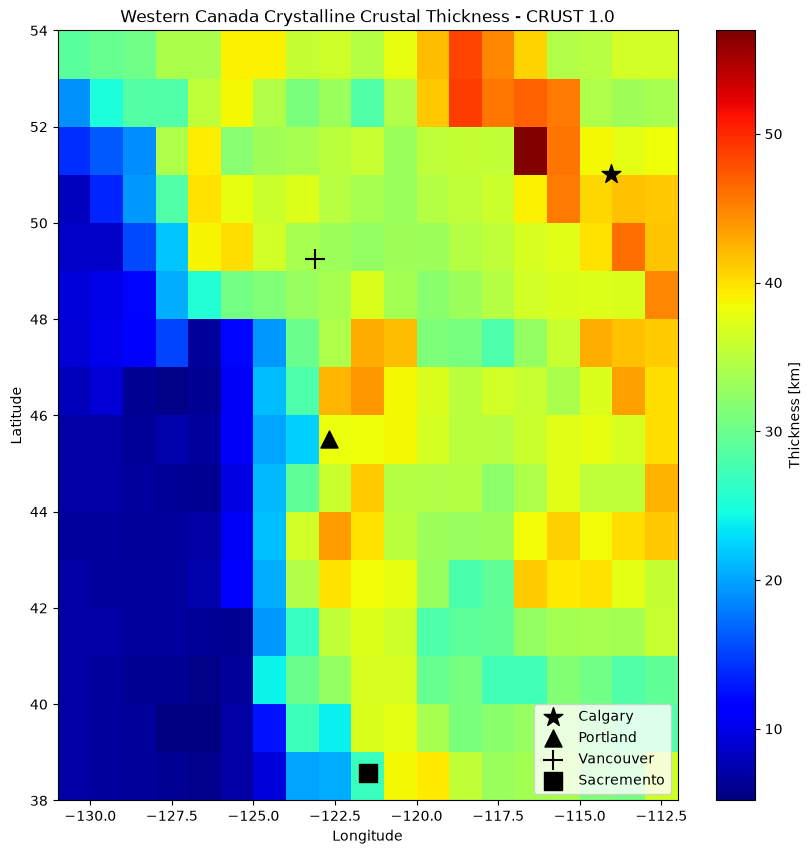

In [49]:
fig, ax100 = plt.subplots(figsize=(10, 10))

pcm_cru_res_na = ax100.pcolormesh(long, lat, crust1_res_na, cmap='jet')
fig.colorbar(pcm_cru_res_na, ax=ax100, label='Thickness [km]')
ax100.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax100.scatter(-122.68, 45.52, marker='^', color='black', s=150, label='Portland')
ax100.scatter(-123.12, 49.26, marker='+', color='black', s=200, label='Vancouver')
ax100.scatter(-121.49, 38.58, marker='s', color='black', s=150, label='Sacremento')


ax100.set_title('Western Canada Crystalline Crustal Thickness - CRUST 1.0')
ax100.set_xlabel('Longitude')
ax100.set_ylabel('Latitude')

plt.legend(loc='lower right')

plt.savefig('..\\..\\figures\\ecm1\\res_crust1.0_cad_grid.png', dpi=400, bbox_inches='tight')
plt.show()

## combined grids

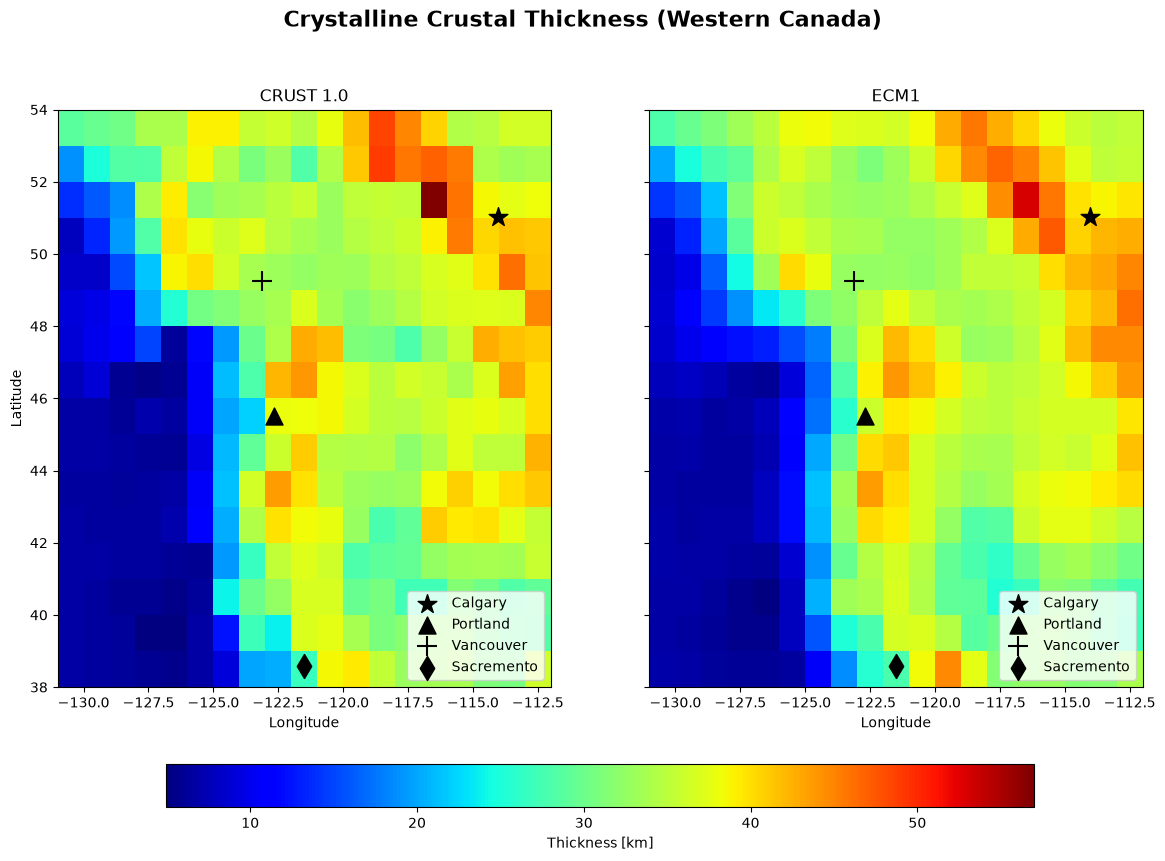

In [60]:
fig, (ax2, ax22) = plt.subplots(1, 2, figsize=(14, 10), sharey=True)

## crust 1.0 cad grid

pcm_cru_res_na = ax2.pcolormesh(long, lat, crust1_res_na, cmap='jet')
ax2.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax2.scatter(-122.68, 45.52, marker='^', color='black', s=150, label='Portland')
ax2.scatter(-123.12, 49.26, marker='+', color='black', s=200, label='Vancouver')
ax2.scatter(-121.49, 38.58, marker='d', color='black', s=150, label='Sacremento')

ax2.set_title('CRUST 1.0')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.legend(loc='lower right')

## ecm1 cad grid 

pcm_hcc_na = ax22.pcolormesh(long, lat, hcc_na, cmap='jet', vmax=57, shading='nearest')
ax22.scatter(-114.03, 51.02, marker='*', color='black', s=200, label='Calgary')
ax22.scatter(-122.68, 45.52, marker='^', color='black', s=150, label='Portland')
ax22.scatter(-123.12, 49.26, marker='+', color='black', s=200, label='Vancouver')
ax22.scatter(-121.49, 38.58, marker='d', color='black', s=150, label='Sacremento')


ax22.set_title('ECM1')
ax22.set_xlabel('Longitude')

## all together

fig.colorbar(pcm_hcc_na, ax=[ax2, ax22], location='bottom', label='Thickness [km]', shrink=0.8, pad=0.1)


plt.legend(loc='lower right')

plt.suptitle('Crystalline Crustal Thickness (Western Canada)', fontsize=16, fontweight='bold')



plt.savefig('..\\..\\figures\\ecm1\\crystal_compare_cad_grid.png', dpi=400, bbox_inches='tight')
plt.show()